In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
forecast_data = xr.open_dataset("./data/surface_pangu_24h.nc")
forecast_data

<xarray.Dataset> Size: 133MB
Dimensions:     (valid_time: 8, longitude: 1440, latitude: 721)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 64B 2025-09-23T01:00:00 ... 2025-...
  * longitude   (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude    (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
Data variables:
    msl         (valid_time, latitude, longitude) float32 33MB ...
    u10         (valid_time, latitude, longitude) float32 33MB ...
    v10         (valid_time, latitude, longitude) float32 33MB ...
    t2m         (valid_time, latitude, longitude) float32 33MB ...

In [3]:
# get data at two time steps
forecast_092301 = forecast_data.sel(valid_time='2025-09-23T01:00:00.000000000')
forecast_092319 = forecast_data.sel(valid_time='2025-09-23T19:00:00.000000000')
# get u v wind
u10_092301 = forecast_092301.u10.data
v10_092301 = forecast_092301.v10.data
u10_092319 = forecast_092319.u10.data
v10_092319 = forecast_092319.v10.data
# calculate wind speed
ws10_092301 = np.sqrt(u10_092301**2 + v10_092301**2)
ws10_092319 = np.sqrt(u10_092319**2 + v10_092319**2)
# coordinates
lon = forecast_data.longitude.values
lat = forecast_data.latitude.values

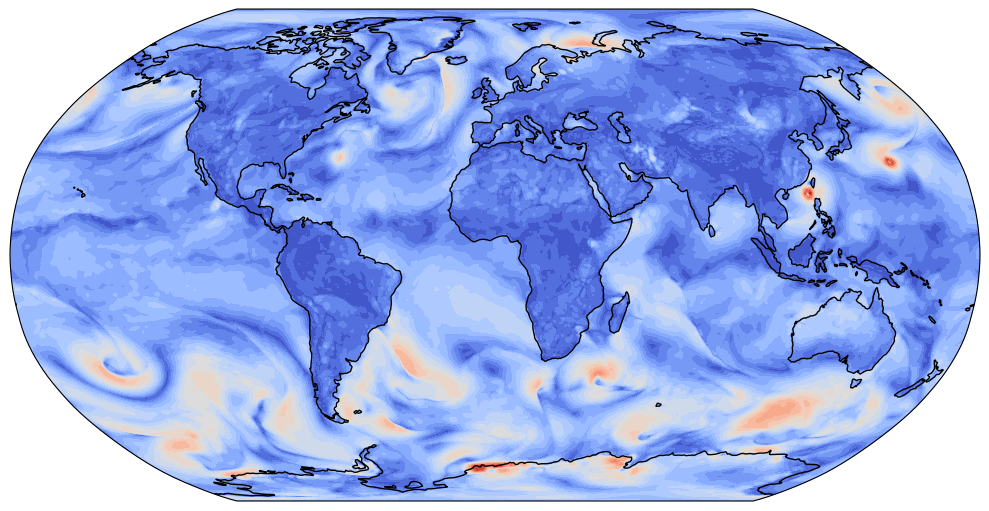

In [4]:
# plot wind speed at 2025-09-23 01:00 UTC

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson()}, figsize=(10, 8))

# plot wind speed
cf = ax.contourf(lon, lat, ws10_092301, levels=20, cmap='coolwarm', transform=ccrs.PlateCarree())
# cb = plt.colorbar(cf, ax=ax, orientation='vertical', shrink=0.8, label='Wind Speed (m/s)')

# map features
ax.coastlines(resolution='110m')
# ax.add_feature(cfeature.BORDERS, linestyle=':')
# ax.set_title('10m Wind Speed - 2025-09-23 01:00 UTC (Pangu 24h Forecast)')
# ax.set_xlabel('Longitude')
# ax.set_ylabel('Latitude')

# gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
# gl.top_labels = False
# gl.right_labels = False

plt.tight_layout()
plt.savefig('./wind_speed_2025092301.tif', dpi=600, bbox_inches='tight')
plt.show()

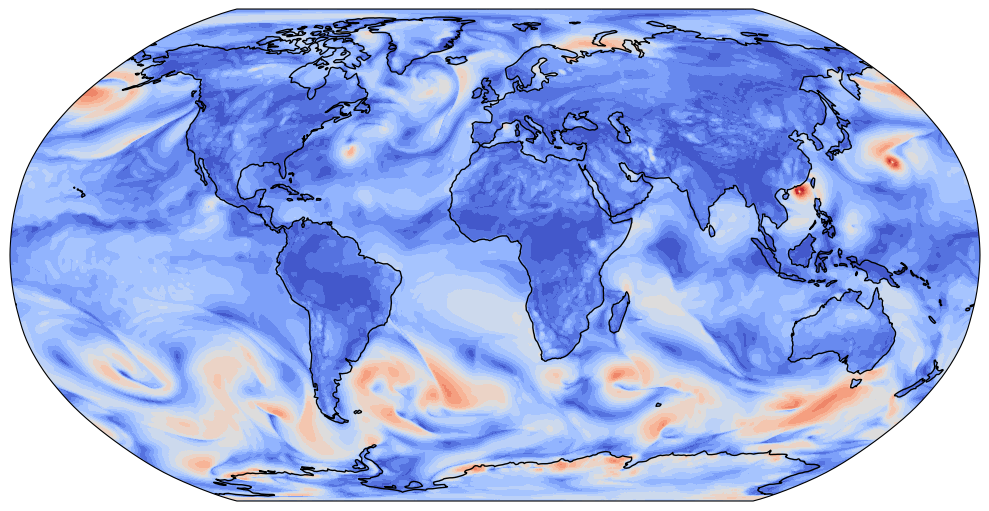

In [5]:
# plot wind speed at 2025-09-23 19:00 UTC

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson()}, figsize=(10, 8))

# plot wind speed
cf = ax.contourf(lon, lat, ws10_092319, levels=20, cmap='coolwarm', transform=ccrs.PlateCarree())
# cb = plt.colorbar(cf, ax=ax, orientation='vertical', shrink=0.8, label='Wind Speed (m/s)')

# map features
ax.coastlines(resolution='110m')
# ax.add_feature(cfeature.BORDERS, linestyle=':')
# ax.set_title('10m Wind Speed - 2025-09-23 01:00 UTC (Pangu 24h Forecast)')
# ax.set_xlabel('Longitude')
# ax.set_ylabel('Latitude')

# gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
# gl.top_labels = False
# gl.right_labels = False

plt.tight_layout()
plt.savefig('./wind_speed_2025092319.tif', dpi=600, bbox_inches='tight')
plt.show()